# **Input Data**

In [4]:
import numpy as np
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [5]:
input_file = '../../data/MentalParameter.csv'

In [6]:
mental_details = pd.read_csv(input_file, index_col=0)

# **Data visualization**

In [7]:
mental_details.info();

<class 'pandas.core.frame.DataFrame'>
Index: 697 entries, 1 to 697
Data columns (total 11 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Age                                              697 non-null    int64  
 1   
Perceived Control                              694 non-null    float64
 2   Stress Frequency and Intensity (Weight: 15%)     695 non-null    object 
 3   
Emotional Regulation                           697 non-null    object 
 4   Physical Symptoms of Stress                      697 non-null    object 
 5   
  
Cognitive Stress (Negative Self-Thoughts)  682 non-null    object 
 6   
Behavioral Response                            692 non-null    object 
 7   Work-Related Stress Factors (Weight: 10%)        687 non-null    float64
 8   Concentration and Productivity (Weight: 10%)     697 non-null    object 
 9   Available Time                            

## **PreProcessing**

In [8]:
mental_details.columns

Index(['Age', '\r\nPerceived Control ',
       'Stress Frequency and Intensity (Weight: 15%)',
       '\r\nEmotional Regulation ', 'Physical Symptoms of Stress',
       '\r\n  \r\nCognitive Stress (Negative Self-Thoughts)',
       '\r\nBehavioral Response ',
       'Work-Related Stress Factors (Weight: 10%) ',
       'Concentration and Productivity (Weight: 10%)', 'Available Time',
       'Suicidal Thoughts (Optional, Use with Caution)'],
      dtype='object')

In [9]:
# Strip spaces from column names
mental_details.columns = mental_details.columns.str.strip()

simplifying column names for improve readability and make modeling or visualizing cleaner

In [10]:
rename_dict = {
    'Age': 'Age',
    'Perceived Control': 'Control',
    'Stress Frequency and Intensity (Weight: 15%)': 'StressFreqIntensity',
    'Emotional Regulation': 'EmotionReg',
    'Physical Symptoms of Stress': 'PhysicalStress',
    'Cognitive Stress (Negative Self-Thoughts)': 'CognitiveStress',
    'Behavioral Response': 'BehaviorResponse',
    'Work-Related Stress Factors (Weight: 10%)': 'WorkStress',
    'Concentration and Productivity (Weight: 10%)': 'Productivity',
    'Available Time': 'FreeTime',
    'Suicidal Thoughts (Optional, Use with Caution)': 'SuicidalThoughts'
}
mental_details.rename(columns=rename_dict, inplace=True)

In [11]:
mental_details.columns

Index(['Age', 'Control', 'StressFreqIntensity', 'EmotionReg', 'PhysicalStress',
       'CognitiveStress', 'BehaviorResponse', 'WorkStress', 'Productivity',
       'FreeTime', 'SuicidalThoughts'],
      dtype='object')

In [12]:
mental_details.head()

,Age,Control,StressFreqIntensity,EmotionReg,PhysicalStress,CognitiveStress,BehaviorResponse,WorkStress,Productivity,FreeTime,SuicidalThoughts
id,,,,,,,,,,,
1,24,1.0,Sometimes (2-3 times),Several days,Several days,Rarely,Rarely,2.0,Several days,50,Several days
2,30,3.0,Sometimes (2-3 times),Several days,Not at all,Sometimes,Sometimes,2.0,Several days,120,Not at all
3,24,1.0,Rarely (0-1 times),Several days,Not at all,Never,Never,1.0,Not at all,120,Not at all
4,28,3.0,Sometimes (2-3 times),Several days,Not at all,Rarely,Sometimes,3.0,Several days,300,Several days
5,24,3.0,Sometimes (2-3 times),Several days,Several days,Sometimes,Sometimes,5.0,Several days,120,Several days


convert the text-based frequency ranges into numerical values

In [13]:
mapping = {
    "Rarely  (0-1 times)": 1,
    "Sometimes (2-3 times)": 2,
    "Often  (4-5 times)": 3,
    "Always (6+ times)": 4
}
mental_details['StressFreqIntensity'] = mental_details['StressFreqIntensity'].map(mapping)

In [14]:
mapping = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3
}
mental_details['EmotionReg'] = mental_details['EmotionReg'].map(mapping)

In [15]:
mapping = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3
}
mental_details['PhysicalStress'] = mental_details['PhysicalStress'].map(mapping)

In [16]:
mapping = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Always": 4
}
mental_details['CognitiveStress'] = mental_details['CognitiveStress'].map(mapping)

In [17]:
mapping = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Always": 4
}
mental_details['BehaviorResponse'] = mental_details['BehaviorResponse'].map(mapping)

In [18]:
mapping = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3
}
mental_details['Productivity'] = mental_details['Productivity'].map(mapping)

In [19]:
mapping = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3
}
mental_details['SuicidalThoughts'] = mental_details['SuicidalThoughts'].map(mapping)

In [20]:
mental_details.head()

,Age,Control,StressFreqIntensity,EmotionReg,PhysicalStress,CognitiveStress,BehaviorResponse,WorkStress,Productivity,FreeTime,SuicidalThoughts
id,,,,,,,,,,,
1,24,1.0,2.0,1,1,1.0,1.0,2.0,1,50,1.0
2,30,3.0,2.0,1,0,2.0,2.0,2.0,1,120,0.0
3,24,1.0,1.0,1,0,0.0,0.0,1.0,0,120,0.0
4,28,3.0,2.0,1,0,1.0,2.0,3.0,1,300,1.0
5,24,3.0,2.0,1,1,2.0,2.0,5.0,1,120,1.0


## **Plot types**

Histogram: Good to see the distribution of values.

Boxplot: Good to quickly spot outliers.

Stripplot / Swarmplot: Good for small datasets to see exact points.

Scatter plot: If you have two columns and want to see the relationship between them.

## **Histogram**

In the context of a histogram, "**bins**" refer to the intervals into which the range of a dataset is divided in order to group the data for frequency analysis. Each bin represents a continuous, non-overlapping range of values, and the height of the bar corresponding to a bin indicates the number of observations (or frequency) that fall within that interval.

In [21]:
def Histogram (df, column, bin):
  plt.hist(df[column], bins=bin)
  plt.xlabel('Value')
  plt.ylabel('Frequency')
  plt.title('Histogram of ' + column)
  plt.show()


## **Boxplot**

A boxplot shows the distribution of a dataset using 5 main numbers:


- **Bottom whisker (line below box):** Minimum value (except outliers)

- **Bottom of box:** 25th percentile (Q1, lower quartile)

- **Middle line inside box:** 50th percentile (Median)

- **Top of box:** 75th percentile (Q3, upper quartile)

- **Top whisker (line above box):** Maximum value (except outliers)

In [22]:
def Boxplot (df, column):
  plt.boxplot(df[column])
  plt.xlabel('Value')
  plt.ylabel('Frequency')
  plt.title('Boxplot of ' + column)
  plt.show()

## **Column-wise Data Exploration**

In [23]:
def CombinedPlots(df, column, bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # First plot: Histogram
    axes[0].hist(df[column], bins=30)
    axes[0].set_title('Histogram of ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    # Second plot: Boxplot
    axes[1].boxplot(df[column])
    axes[1].set_title('Boxplot of' + column)
    axes[1].set_xlabel(column)

    plt.tight_layout()
    plt.show()

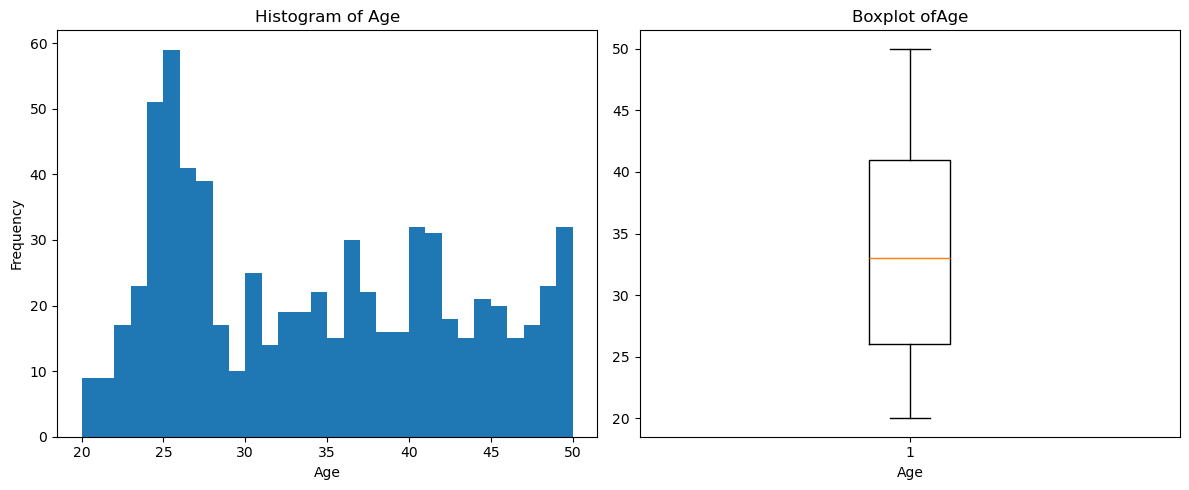

In [24]:
CombinedPlots(mental_details,'Age', 30)

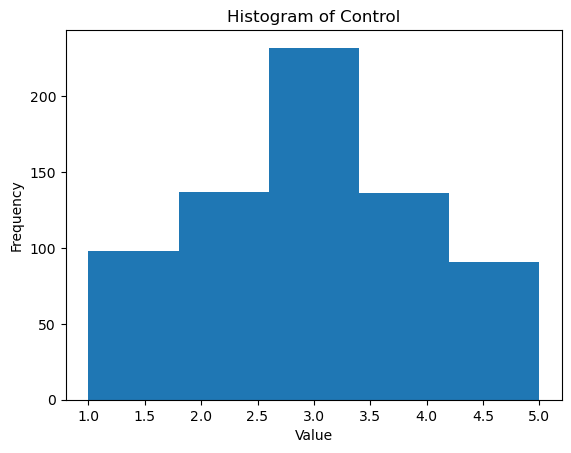

In [25]:
Histogram(mental_details,'Control', 5)

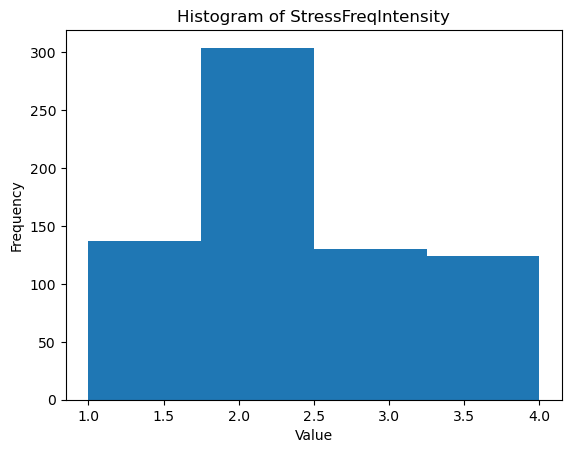

In [26]:
Histogram(mental_details,'StressFreqIntensity', 4)

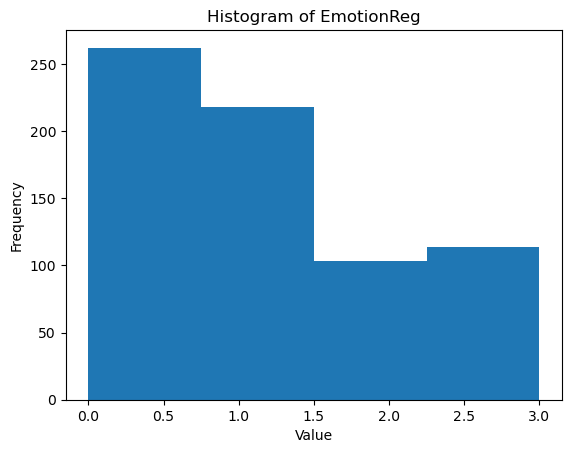

In [27]:
Histogram(mental_details,'EmotionReg', 4)

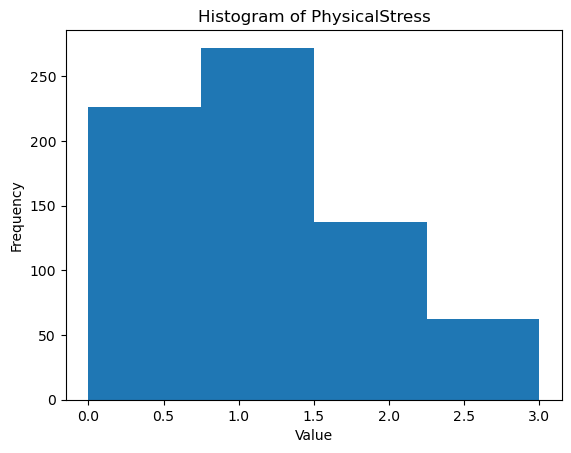

In [28]:
Histogram(mental_details,'PhysicalStress', 4)

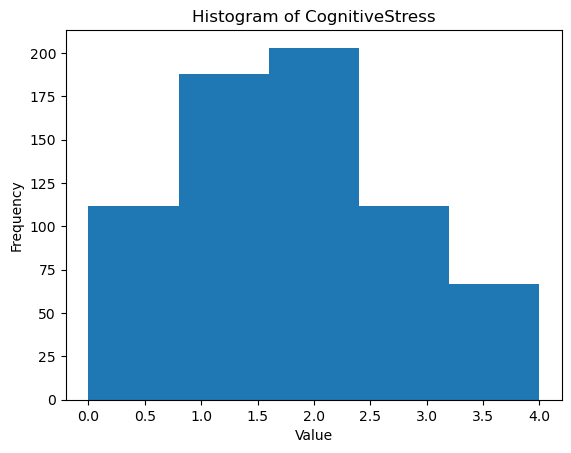

In [29]:
Histogram(mental_details,'CognitiveStress', 5)

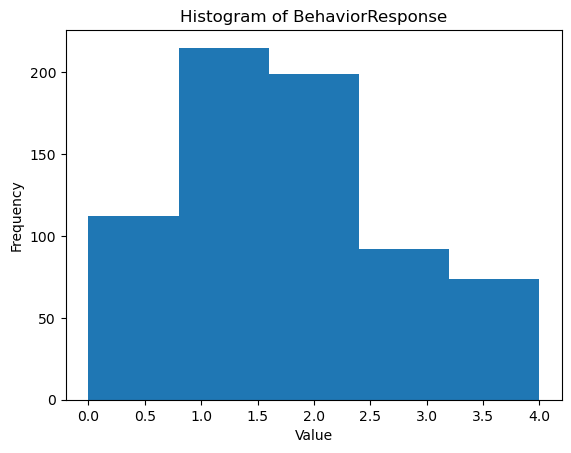

In [30]:
Histogram(mental_details,'BehaviorResponse', 5)

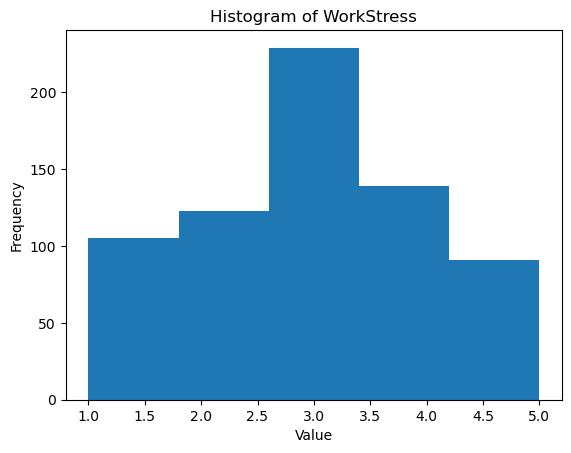

In [31]:
Histogram(mental_details,'WorkStress', 5)

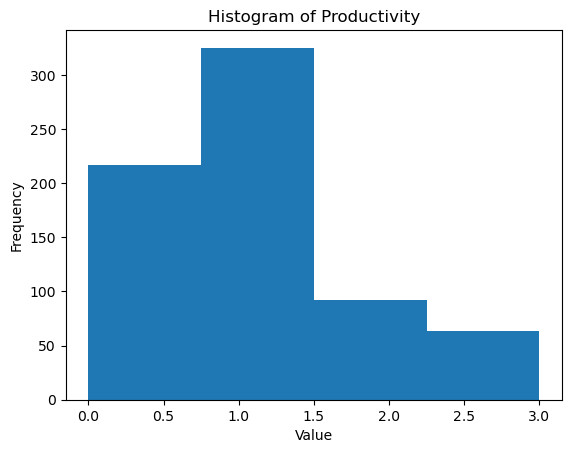

In [32]:
Histogram(mental_details,'Productivity', 4)

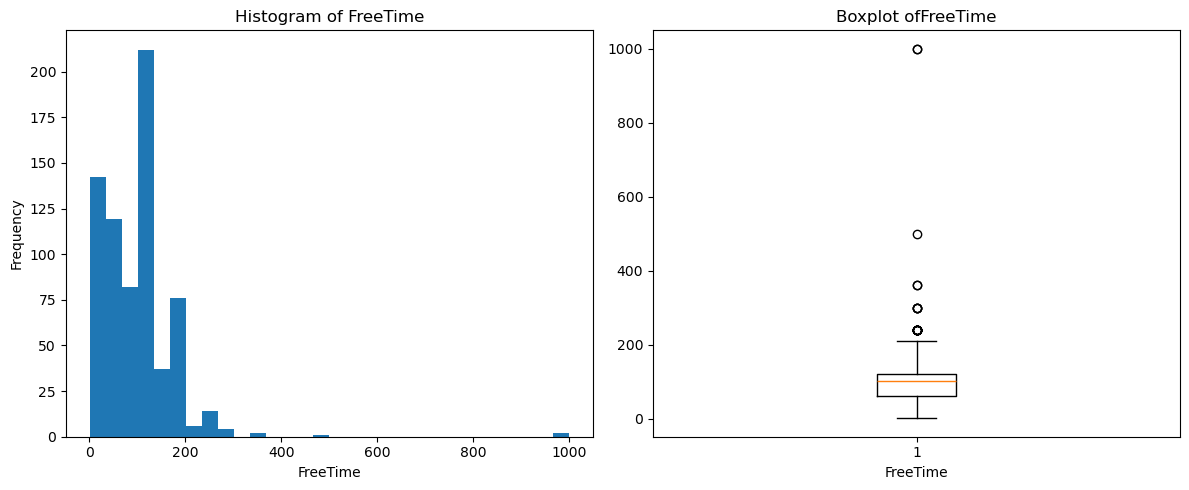

In [33]:
CombinedPlots(mental_details,'FreeTime', 30)

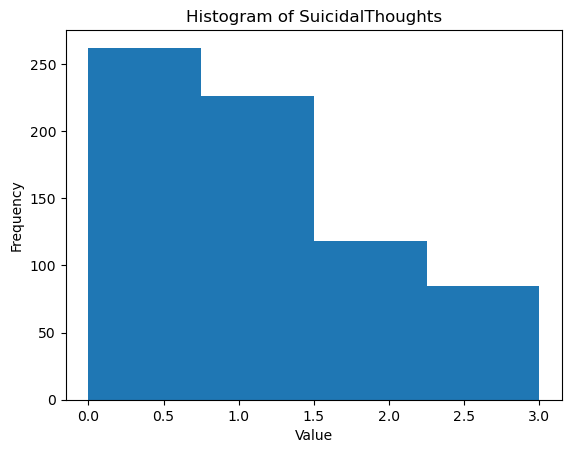

In [34]:
Histogram(mental_details,'SuicidalThoughts', 4)

## FreeTime Categorization

The continuous FreeTime variable was binned into four categories to reduce noise from extreme outliers and simplify modeling. The categories reflect different levels of personal time available per individual:

Very Low (0–50),

Low (51–120),

Moderate (121–300),

High (>300).

These categories were then numerically encoded from 0 to 3 in ascending order to maintain ordinal relationships, which are suitable for most machine learning algorithms that benefit from ordered numerical input (e.g., tree-based models, logistic regression).

This transformation helps reduce the skewness caused by outliers and improves model interpretability.

In [35]:
def categorize_freetime(value):
    if value <= 50:
        return 0
    elif value <= 120:
        return 1
    elif value <= 300:
        return 2
    else:
        return 3

mental_details["FreeTime"] = mental_details["FreeTime"].map(categorize_freetime)

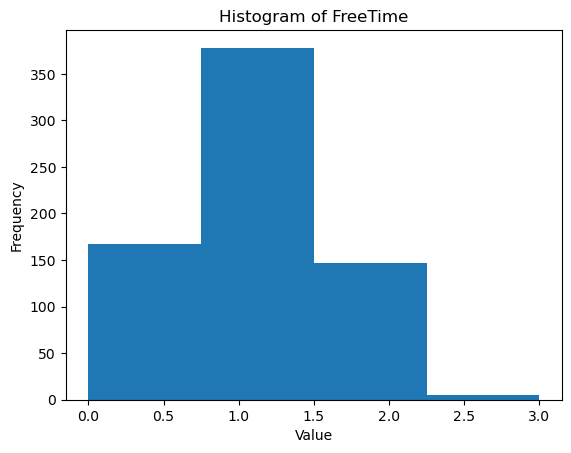

In [36]:
Histogram(mental_details,'FreeTime', 4)

In [42]:
mental_details.info()

<class 'pandas.core.frame.DataFrame'>
Index: 697 entries, 1 to 697
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  697 non-null    int64  
 1   Control              694 non-null    float64
 2   StressFreqIntensity  695 non-null    float64
 3   EmotionReg           697 non-null    int64  
 4   PhysicalStress       697 non-null    int64  
 5   CognitiveStress      682 non-null    float64
 6   BehaviorResponse     692 non-null    float64
 7   WorkStress           687 non-null    float64
 8   Productivity         697 non-null    int64  
 9   FreeTime             697 non-null    int64  
 10  SuicidalThoughts     691 non-null    float64
 11  Stress_Level         697 non-null    object 
dtypes: float64(6), int64(5), object(1)
memory usage: 70.8+ KB
